# ライブラリの読み込み

In [1]:
import onnxruntime as ort
# モデルの読み込み
fastbev = ort.InferenceSession(
     "./onnx/fastbev.onnx",
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
    #providers=["CPUExecutionProvider"]
)

In [11]:
trt_options = {
    "trt_engine_cache_enable": True,
    "trt_engine_cache_path": "./trt_cache",
    "trt_fp16_enable": False,
    "trt_int8_enable": False,
}

fastbev = ort.InferenceSession(
    "./onnx/fastbev.onnx",
    providers=[
        ("TensorrtExecutionProvider", trt_options),
        ("CUDAExecutionProvider", {"device_id": 0}),
        "CPUExecutionProvider",
    ],
)

2026-05-06 04:40:57.365844931 [W:onnxruntime:Default, tensorrt_execution_provider.h:91 log] [2026-05-05 19:40:57 WARNING] ModelImporter.cpp:459: Make sure input coors_img has Int64 binding.
2026-05-06 04:40:57.365862919 [W:onnxruntime:Default, tensorrt_execution_provider.h:91 log] [2026-05-05 19:40:57 WARNING] ModelImporter.cpp:459: Make sure input coors_depth has Int64 binding.
2026-05-06 04:40:57.440332777 [W:onnxruntime:Default, tensorrt_execution_provider.h:91 log] [2026-05-05 19:40:57 WARNING] ModelImporter.cpp:459: Make sure input coors_img has Int64 binding.
2026-05-06 04:40:57.440365534 [W:onnxruntime:Default, tensorrt_execution_provider.h:91 log] [2026-05-05 19:40:57 WARNING] ModelImporter.cpp:459: Make sure input coors_depth has Int64 binding.


In [12]:
print("available providers:", ort.get_available_providers())
print("session providers  :", fastbev.get_providers())

available providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
session providers  : ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


In [13]:
fastbev_4d = ort.InferenceSession(
    "./onnx/fastbev_4d.onnx",
    providers=[
        ("TensorrtExecutionProvider", trt_options),
        ("CUDAExecutionProvider", {"device_id": 0}),
        "CPUExecutionProvider",
    ],
)

print("session providers:", fastbev_4d.get_providers())

session providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


In [14]:
print("Session providers:", fastbev.get_providers())

Session providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


In [7]:
# ライブラリ
import numpy as np
import torch
import onnxruntime as ort
import torch.nn.functional as F
from IPython.display import clear_output, display
import matplotlib.pyplot as plt

from nuscenes_sample_generator import NuScenesSampleGenerator
from img_pipeline import PrepareImageInputs
from onnx_input_builder import OnnxInputBuilder
from bbox_decoder import BboxDecoder
from visualizer import Visualizer 
from util import load_config, load_json

import matplotlib.pyplot as plt
import time

# 設定ファイルの読み込み設定

In [2]:
# パスの設定
json_path   = "bevdetv3-nuscenes_infos_val.json"
config_path = "config.yaml"

# 初期化処理

In [3]:
# jsonファイルとconfigファイルの読み込み
json_file   = load_json(json_path)
data_config = load_config(config_path)

# sample Generator
data_infos = json_file['infos']
sample_generator = NuScenesSampleGenerator(data_infos=data_infos, num_adj_frame=1)

# image pipeline
image_pipline = PrepareImageInputs(data_config["data_config"], sequential=True, opencv_pp=False)

# 入力データの作成
grid_config = data_config["geometry"]["grid_config"]
image_size  = data_config["data_config"]["input_size"]
onnx_input_builder = OnnxInputBuilder(grid_config, image_size, stride=16, accelerate=True)

# モデルの後処理
post_center_range = data_config["bbox_decoder"]["post_center_range"]
max_num           = data_config["bbox_decoder"]["max_num"]
num_classes       = data_config["bbox_decoder"]["num_classes"]
score_threshold   = data_config["bbox_decoder"]["score_threshold"]
bbox_decoder = BboxDecoder(post_center_range, max_num, num_classes, None)

# 可視化
save_path   = data_config["visualizer"]["save_path"]
save_format = data_config["visualizer"]["save_format"]
save_prefix = data_config["visualizer"]["save_prefix"]
fps         = data_config["visualizer"]["fps"]
visualizer  = Visualizer(0.5, save_path, save_format, save_prefix, fps, scale_factor=3, color_map=(0, 255, 255))

# モデルの読み込み
fastbev = ort.InferenceSession(
     "./onnx/fastbev.onnx",
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
#    #providers=["CPUExecutionProvider"]
)

fastbev4d = ort.InferenceSession(
    "./onnx/fastbev_4d.onnx",
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
    #providers=["CPUExecutionProvider"]
)

2026-05-10 17:06:14.889445073 [W:onnxruntime:Default, scatter_nd.h:51 ScatterNDWithAtomicReduction] ScatterND with reduction=='none' only guarantees to be correct if indices are not duplicated.
2026-05-10 17:06:14.889461214 [W:onnxruntime:Default, scatter_nd.h:51 ScatterNDWithAtomicReduction] ScatterND with reduction=='none' only guarantees to be correct if indices are not duplicated.
2026-05-10 17:06:14.889486103 [W:onnxruntime:Default, scatter_nd.h:51 ScatterNDWithAtomicReduction] ScatterND with reduction=='none' only guarantees to be correct if indices are not duplicated.
2026-05-10 17:06:14.889492799 [W:onnxruntime:Default, scatter_nd.h:51 ScatterNDWithAtomicReduction] ScatterND with reduction=='none' only guarantees to be correct if indices are not duplicated.
2026-05-10 17:06:14.889513140 [W:onnxruntime:Default, scatter_nd.h:51 ScatterNDWithAtomicReduction] ScatterND with reduction=='none' only guarantees to be correct if indices are not duplicated.
2026-05-10 17:06:14.889518525 

# ウォームアップ

In [4]:
def run_fastbev_onnx(
    input_data,
    fastbev,
    fastbev4d,
    onnx_input_builder,
):
    """
    1サンプル分のinput_dataを使って、
    FastBEV ONNX + FastBEV4D ONNX の推論を実行する。

    Args:
        input_data:
            image_pipline適用後の入力データ。

        fastbev:
            FastBEV前段ONNX Runtime InferenceSession。

        fastbev4d:
            FastBEV4D後段ONNX Runtime InferenceSession。

        onnx_input_builder:
            coors_img/coors_depth作成、shift_featureに使うクラス。

    Returns:
        detections:
            fastbev4dの出力。
    """

    img_curr, sensor2keyegos_curr, ego2globals_curr, intrins_curr, post_rots_curr, post_trans_curr, bda_curr = input_data["img_inputs_curr"]
    img_prev, sensor2keyegos_prev, ego2globals_prev, intrins_prev, post_rots_prev, post_trans_prev, bda_prev = input_data["img_inputs_prev"]

    # 現在フレームの入力作成
    _, coors_img_curr, coors_depth_curr = onnx_input_builder.get_fastray_input(
        input_data["img_inputs_curr"]
    )
    coors_img_curr, coors_depth_curr = coors_img_curr[0], coors_depth_curr[0]

    # 過去フレームの入力作成
    input_data["img_inputs_prev"][1] = input_data["img_inputs_curr"][1]
    input_data["img_inputs_prev"][2] = input_data["img_inputs_curr"][2]

    _, coors_img_prev, coors_depth_prev = onnx_input_builder.get_fastray_input(
        input_data["img_inputs_prev"]
    )
    coors_img_prev, coors_depth_prev = coors_img_prev[0], coors_depth_prev[0]

    # 現在フレームのBEV特徴量
    bev_feat_curr_onnx = fastbev.run(
        ["bev_feat"],
        {
            "img": img_curr.squeeze(0).cpu().numpy().astype(np.float32),
            "coors_img": coors_img_curr.cpu().numpy().astype(np.int64),
            "coors_depth": coors_depth_curr.cpu().numpy().astype(np.int64),
        }
    )[0]

    # 過去フレームのBEV特徴量
    bev_feat_prev_onnx = fastbev.run(
        ["bev_feat"],
        {
            "img": img_prev.squeeze(0).cpu().numpy().astype(np.float32),
            "coors_img": coors_img_prev.cpu().numpy().astype(np.int64),
            "coors_depth": coors_depth_prev.cpu().numpy().astype(np.int64),
        }
    )[0]

    # 後段処理のためtorchに戻す
    bev_feat_curr = torch.from_numpy(bev_feat_curr_onnx).float()
    bev_feat_prev = torch.from_numpy(bev_feat_prev_onnx).float()

    # 過去フレームBEVを現在フレームに位置合わせ
    bev_feat_prev = onnx_input_builder.shift_feature(
        bev_feat_prev,
        [sensor2keyegos_curr, sensor2keyegos_prev],
        bda_curr
    )

    # BEV特徴を結合
    bev_feats = torch.cat([bev_feat_curr, bev_feat_prev], dim=1)

    # 物体認識
    detections = fastbev4d.run(
        None,
        {
            "bev_feats": bev_feats.cpu().numpy().astype(np.float32)
        }
    )

    return detections

In [5]:
def warmup_fastbev_onnx(
    sample_generator,
    image_pipline,
    fastbev,
    fastbev4d,
    onnx_input_builder,
    warmup_num=20,
    sample_index=0,
):
    """
    ONNX Runtime推論のwarmupを行う。

    Args:
        sample_generator:
            NuScenesSampleGeneratorなど。

        image_pipline:
            前処理クラス。

        fastbev:
            FastBEV前段ONNX Runtime InferenceSession。

        fastbev4d:
            FastBEV4D後段ONNX Runtime InferenceSession。

        onnx_input_builder:
            ONNX入力作成用クラス。

        warmup_num:
            warmup回数。

        sample_index:
            warmupに使うサンプル番号。
    """

    input_data = sample_generator.get_data_info(sample_index)
    input_data = image_pipline(input_data)

    for _ in range(warmup_num):
        _ = run_fastbev_onnx(
            input_data=input_data,
            fastbev=fastbev,
            fastbev4d=fastbev4d,
            onnx_input_builder=onnx_input_builder,
        )

    print(f"warmup done: {warmup_num} loops")

In [17]:
# warmup
warmup_fastbev_onnx(
    sample_generator=sample_generator,
    image_pipline=image_pipline,
    fastbev=fastbev,
    fastbev4d=fastbev4d,
    onnx_input_builder=onnx_input_builder,
    warmup_num=20,
    sample_index=0,
)

warmup done: 20 loops


# 推論処理

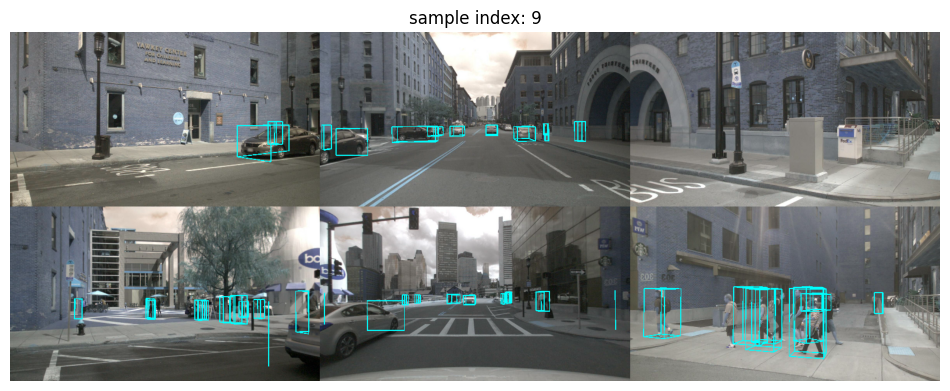

In [18]:
# 時間計測結果
task_latencies = {
    "sample_generator" : [],
    "image_pipeline"   : [],
    "get_fastray_input": [],
    "fastbev"          : [],
    "shift_bev"        : [],
    "fastbev4d"        : [],
    "decode"           : [],
    "visualize"        : [],
    "total"            : [],
}

with torch.no_grad():
    for i in range(len(data_infos)):
        #if i<1:
        #    continue
            
        if i>=10:
            break

        # 時間計測開始
        torch.cuda.synchronize()
        start_total = time.perf_counter()
        
        ########################################
        # 入力データを過去と現在フレームに分ける
        ########################################
        # 時間計測開始
        torch.cuda.synchronize()
        start_sample = time.perf_counter()

        input_data = sample_generator.get_data_info(i)

        # 時間計測終了
        torch.cuda.synchronize()
        end_sample = time.perf_counter()
        sample_generator_latency = (end_sample - start_sample)*1000
        task_latencies["sample_generator"].append(sample_generator_latency)

        ########################################
        # 画像パイプライン
        ########################################
        # 時間計測開始
        torch.cuda.synchronize()
        start_pipline = time.perf_counter()
        
        input_data = image_pipline(input_data)
        img_curr, sensor2keyegos_curr, ego2globals_curr, intrins_curr, post_rots_curr, post_trans_curr, bda_curr = input_data["img_inputs_curr"]
        img_prev, sensor2keyegos_prev, ego2globals_prev, intrins_prev, post_rots_prev, post_trans_prev, bda_prev = input_data["img_inputs_prev"]

        # 時間計測終了
        torch.cuda.synchronize()
        end_pipline = time.perf_counter()
        image_pipline_latency = (end_pipline - start_pipline)*1000
        task_latencies["image_pipeline"].append(image_pipline_latency)

        ########################################
        # 画像特徴量の抽出 & 2D→3Dへの変換表作成
        ########################################
        # 時間計測開始
        torch.cuda.synchronize()
        start_fastray_input = time.perf_counter()
        
        # FastBEVモデルの入力データ作成(現在フレームの入力データ)
        _, coors_img_curr, coors_depth_curr = onnx_input_builder.get_fastray_input(input_data["img_inputs_curr"]) # 事前計算済みの座標変換情報
        coors_img_curr, coors_depth_curr = coors_img_curr[0], coors_depth_curr[0]
        
        # FastBEVモデルの入力データ作成(過去フレームの入力データ)
        # align_after_view_transfromationの対応
        input_data["img_inputs_prev"][1] = input_data["img_inputs_curr"][1] # sensor2keyegos
        input_data["img_inputs_prev"][2] = input_data["img_inputs_curr"][2] # ego2global
        _, coors_img_prev, coors_depth_prev = onnx_input_builder.get_fastray_input(input_data["img_inputs_prev"]) # 事前計算済みの座標変換情報
        coors_img_prev, coors_depth_prev = coors_img_prev[0], coors_depth_prev[0]

        # ONNX用にnumpyに変換
        img_curr_np = img_curr.squeeze(0).cpu().numpy().astype(np.float32)
        coors_img_curr_np = coors_img_curr.cpu().numpy().astype(np.int64)
        coors_depth_curr_np = coors_depth_curr.cpu().numpy().astype(np.int64)
        
        img_prev_np = img_prev.squeeze(0).cpu().numpy().astype(np.float32)
        coors_img_prev_np = coors_img_prev.cpu().numpy().astype(np.int64)
        coors_depth_prev_np = coors_depth_prev.cpu().numpy().astype(np.int64)

        # 時間計測終了
        torch.cuda.synchronize()
        end_fastray_input = time.perf_counter()
        get_fastray_input_latency = (end_fastray_input - start_fastray_input)*1000
        task_latencies["get_fastray_input"].append(get_fastray_input_latency)

        ########################################
        # BEV特徴量の作成
        ########################################
        # 時間計測開始
        torch.cuda.synchronize()
        start_fastbev = time.perf_counter()
        
        # 現在フレーム
        bev_feat_curr_onnx = fastbev.run(
            ["bev_feat"],
            {
                "img": img_curr_np,
                "coors_img": coors_img_curr_np,
                "coors_depth": coors_depth_curr_np,
            }
        )[0] 

        # 過去フレーム
        bev_feat_prev_onnx = fastbev.run(
            ["bev_feat"],
            {
                "img": img_prev_np,
                "coors_img": coors_img_prev_np,
                "coors_depth": coors_depth_prev_np,
            }
        )[0] 

        # 時間計測終了
        torch.cuda.synchronize()
        end_fastbev = time.perf_counter()
        fastbev_latency = (end_fastbev - start_fastbev)*1000
        task_latencies["fastbev"].append(fastbev_latency)

        ########################################
        # BEV特徴量の結合
        ########################################
        # 時間計測開始
        torch.cuda.synchronize()
        start_shift = time.perf_counter()

        # 後段の処理のために、一旦torchに戻す
        bev_feat_curr = torch.from_numpy(bev_feat_curr_onnx).float()
        bev_feat_prev = torch.from_numpy(bev_feat_prev_onnx).float()
            
        # BEVの結合
        bev_feat_list = [bev_feat_curr, bev_feat_prev]
        bev_feat_list[1] = onnx_input_builder.shift_feature(bev_feat_list[1], [sensor2keyegos_curr, sensor2keyegos_prev], bda_curr)
        bev_feats = torch.cat(bev_feat_list, dim=1)

        # ONNX用にnumpyに変換
        bev_feats_np = bev_feats.cpu().numpy()

        # 時間計測終了
        torch.cuda.synchronize()
        end_shift = time.perf_counter()
        shift_latency = (end_shift - start_shift)*1000
        task_latencies["shift_bev"].append(shift_latency)

        ########################################
        # 物体認識
        ########################################
        # 時間計測開始
        torch.cuda.synchronize()
        start_fastbev4d = time.perf_counter()
        
        detections = fastbev4d.run(
            None,
            {"bev_feats": bev_feats_np}
        )

        # 時間計測終了
        torch.cuda.synchronize()
        end_fastbev4d = time.perf_counter()
        fastbev4d_latency = (end_fastbev4d - start_fastbev4d)*1000
        task_latencies["fastbev4d"].append(fastbev4d_latency)

        ########################################
        # 後処理
        ########################################
        # 時間計測開始
        torch.cuda.synchronize()
        start_decode = time.perf_counter()
        
        # 後処理
        detections = [torch.from_numpy(detection).float() for detection in detections] # torchに戻す
        bboxes, scores, labels = bbox_decoder.get_bbox(detections)

        # 時間計測終了
        torch.cuda.synchronize()
        end_decode = time.perf_counter()
        decode_latency = (end_decode - start_decode)*1000
        task_latencies["decode"].append(decode_latency)

        
        ########################################
        # 可視化
        ########################################
        # 時間計測開始
        torch.cuda.synchronize()
        start_visualize = time.perf_counter()
        
        nusc_results, nusc_annos = visualizer.format_bbox(bboxes, scores, labels, data_infos[i]) # nuscenesに座標変換        
        drawed_img = visualizer.draw_bbox(nusc_results, data_infos[i], i)
        
        clear_output(wait=True)
        plt.figure(figsize=(12, 8))
        plt.imshow(drawed_img)
        plt.title(f"sample index: {i}")
        plt.axis("off")
        plt.show()

        # 時間計測終了
        torch.cuda.synchronize()
        end_visualize = time.perf_counter()
        visualize_latency = (end_visualize - start_visualize)*1000
        task_latencies["visualize"].append(visualize_latency)

        # 時間計測終了
        end_total = time.perf_counter()
        total_latency = (end_total - start_total)*1000
        task_latencies["total"].append(total_latency)

# 処理時間の表示

In [19]:
for task, latencies in task_latencies.items():
    if task == "get_fastray_input" or task == "fastbev":
        latency = sum(latencies) / (len(latencies)*2)
    else:
        latency = sum(latencies) / len(latencies)
        
    print(f"{task}:{latency}[ms]")

sample_generator:0.04171369946561754[ms]
image_pipeline:257.8946346970042[ms]
get_fastray_input:4654.477443899668[ms]
fastbev:51.226273947395384[ms]
shift_bev:12.257982898154296[ms]
fastbev4d:22.572114705690183[ms]
decode:0.7548543013399467[ms]
visualize:326.22110650117975[ms]
total:10031.338209900423[ms]


In [12]:
task_latencies

{'sample_generator': [0.029992981581017375,
  0.09123800555244088,
  0.06717201904393733,
  0.030903000151738524,
  0.04979100776836276,
  0.09390400373376906,
  0.04913698649033904,
  0.06607602699659765,
  0.0328739988617599,
  0.1584359852131456],
 'image_pipeline': [281.68008400825784,
  254.66477699228562,
  242.36837300122716,
  299.64934900635853,
  245.58296700706705,
  262.1769040124491,
  282.1293539891485,
  277.71115000359714,
  290.1987209916115,
  324.17079000151716],
 'get_fastray_input': [9602.362965990324,
  9411.05322499061,
  9158.793517999584,
  9698.328658007085,
  9411.24692800804,
  9367.022019985598,
  9724.184165999759,
  9060.069261991885,
  9850.702672003536,
  8916.191447002348],
 'fastbev': [115.62803800916299,
  102.25373299908824,
  99.764154991135,
  101.78758701658808,
  101.71545998309739,
  103.28536899760365,
  108.40427299262956,
  102.10023500258103,
  108.05273699224927,
  101.50358799728565],
 'shift_bev': [8.889049000572413,
  12.556194997159764

In [20]:
torch.cuda.synchronize()
start_cuda = time.perf_counter()

bev_feat_prev_gpu = torch.from_numpy(bev_feat_prev_onnx).float().cuda()
sensor2keyegos_curr_gpu = sensor2keyegos_curr.cuda()
sensor2keyegos_prev_gpu = sensor2keyegos_prev.cuda()
bda_curr_gpu = bda_curr.cuda()

# 時間計測終了
torch.cuda.synchronize()
end_cuda = time.perf_counter()
cuda_latency = (end_cuda - start_cuda)*1000
print(cuda_latency)

43.87891601072624
